In [1]:
import pandas as pd

# Charger les fichiers
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
gender_submission = pd.read_csv("gender_submission.csv")

# Vérifier la taille initiale
print("Train avant :", len(train))
print("Test avant :", len(test))
print("Gender_submission avant :", len(gender_submission))

# Détection des doublons
print("Doublons dans train :", train.duplicated().sum())
print("Doublons dans test :", test.duplicated().sum())
print("Doublons dans gender_submission :", gender_submission.duplicated().sum())

# Suppression des doublons
train_clean = train.drop_duplicates()
test_clean = test.drop_duplicates()
gender_submission_clean = gender_submission.drop_duplicates()

# Vérifier la taille après suppression
print("Train après :", len(train_clean))
print("Test après :", len(test_clean))
print("Gender_submission après :", len(gender_submission_clean))

# (Optionnel) Sauvegarder les fichiers nettoyés
train_clean.to_csv("train_clean.csv", index=False)
test_clean.to_csv("test_clean.csv", index=False)
gender_submission_clean.to_csv("gender_submission_clean.csv", index=False)


Train avant : 891
Test avant : 418
Gender_submission avant : 418
Doublons dans train : 0
Doublons dans test : 0
Doublons dans gender_submission : 0
Train après : 891
Test après : 418
Gender_submission après : 418


🌟 Exercice 2 : Gestion des valeurs manquantes

In [11]:
import pandas as pd
from sklearn.impute import SimpleImputer

# ==========================================
# 0. CHARGEMENT DES DONNÉES
# ==========================================
train = pd.read_csv("train.csv")

# ==========================================
# 1. IDENTIFIER LES VALEURS MANQUANTES
# ==========================================
print("--- Valeurs manquantes avant nettoyage ---")
print(train.isnull().sum())

# ==========================================
# 2. APPLIQUER LES STRATÉGIES
# ==========================================

# Stratégie A : Imputation par la médiane (Colonne 'Age')
# 177 valeurs manquantes → on conserve toutes les lignes
imputer_age = SimpleImputer(strategy="median")
train[["Age"]] = imputer_age.fit_transform(train[["Age"]])

# Stratégie B : Remplissage par le mode (Colonne 'Embarked')
# Seulement 2 NaN → le mode est plus pertinent qu'une suppression
# qui ferait perdre 2 lignes sans raison
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

# Stratégie C : Suppression de la colonne (Colonne 'Cabin')
# 687 NaN sur 891 lignes (77%) → trop creuse pour être imputée utilement
# On supprime la colonne entière plutôt que les lignes
train = train.drop(columns=["Cabin"])

# ==========================================
# 3. VÉRIFICATION FINALE
# ==========================================
print("\n--- Valeurs manquantes après nettoyage ---")
print(train.isnull().sum())

--- Valeurs manquantes avant nettoyage ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Valeurs manquantes après nettoyage ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


🌟 Exercice 3 : Ingénierie des fonctionnalité

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# ==========================================
# 1. CRÉATION DE LA TAILLE DE LA FAMILLE
# ==========================================
# On additionne les conjoints/fratries, les parents/enfants, plus le passager lui-même (+1)
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1


# ==========================================
# 2. EXTRACTION DU TITRE DEPUIS LE NOM
# ==========================================
# On utilise une expression régulière (Regex) pour extraire le texte.
# L'instruction ' ([A-Za-z]+)\.' signifie : "Cherche un espace, suivi de lettres, suivi d'un point."
train["Title"] = train["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)


# ==========================================
# 3. ENCODAGE DES VARIABLES CATÉGORIELLES
# ==========================================

# Méthode A : Label Encoding (Parfait pour 2 catégories comme le sexe)
encoder = LabelEncoder()
train["Sex"] = encoder.fit_transform(train["Sex"]) 
# 'female' devient 0, 'male' devient 1

# Il faut s'assurer que la colonne Embarked (où l'on a supprimé les vides) 
# et la nouvelle colonne Title soient bien en format texte classique avant le One-Hot
train["Embarked"] = train["Embarked"].astype(str)
train["Title"] = train["Title"].astype(str)

# Méthode B : One-Hot Encoding (Parfait pour les catégories multiples sans hiérarchie)
# get_dummies va créer une nouvelle colonne pour chaque titre et chaque port
train = pd.get_dummies(train, columns=["Embarked", "Title"], drop_first=True)


# ==========================================
# 4. VÉRIFICATION
# ==========================================
# Affichons les 5 premières lignes pour voir nos nouvelles colonnes
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  ... Title_Major  Title_Master  Title_Miss  \
0         A/5 21171   7.2500  ...       False         False       False   
1          PC 17599  71.2833  ...       False         False       False   
2  STON/O2. 3101282   7.9250  ...       False         False        True

<>:16: SyntaxWarning: invalid escape sequence '\.'
<>:16: SyntaxWarning: invalid escape sequence '\.'
C:\Users\ndev\AppData\Local\Temp\ipykernel_13256\492448774.py:16: SyntaxWarning: invalid escape sequence '\.'
  train["Title"] = train["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)


🌟 Exercice 4 : Détection et traitement des valeurs aberrantes

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  

Matplotlib is building the font cache; this may take a moment.


Borne supérieure IQR pour Fare : 65.6344


Age            Axes(0.125,0.11;0.352273x0.77)
Fare_log    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

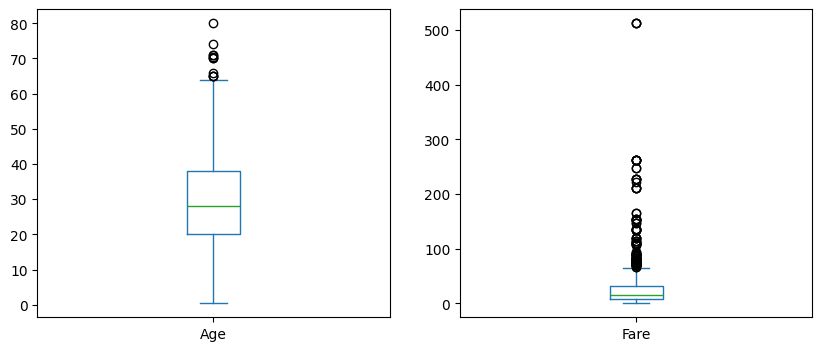

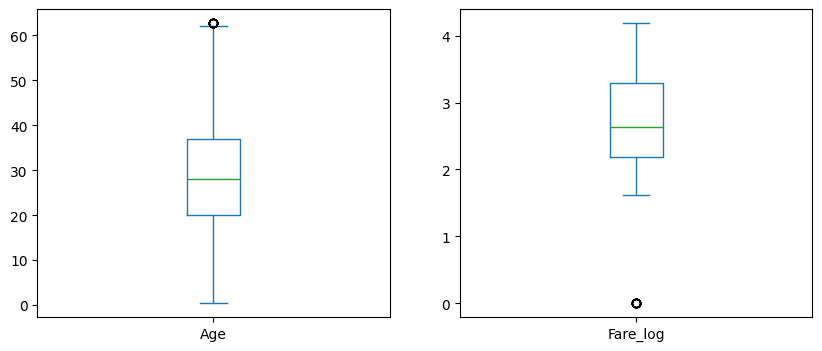

In [ ]:

# Charge le fichier
train = pd.read_csv("train.csv")
print("Données chargées avec succès !")


# ==========================================
# 1. VISUALISATION — Avant traitement
# ==========================================
train[["Age", "Fare"]].plot(kind='box', subplots=True, layout=(1,2), figsize=(10,4))
plt.suptitle("Avant traitement")  # ← ajout : titre pour distinguer avant/après
plt.tight_layout()
plt.show()


# ==========================================
# 2. DÉTECTION — Méthode IQR sur Fare
# ==========================================
Q1 = train["Fare"].quantile(0.25)
Q3 = train["Fare"].quantile(0.75)
IQR = Q3 - Q1
borne_sup = Q3 + 1.5 * IQR
print(f"Borne supérieure IQR pour Fare : {borne_sup:.2f}")
print(f"Outliers détectés : {(train['Fare'] > borne_sup).sum()} lignes")



train_clean = train.copy()

# A. Plafonnement — Age au 98e percentile
limite_age = train_clean["Age"].quantile(0.98)
train_clean["Age"] = train_clean["Age"].clip(upper=limite_age)

# B. Transformation log — Fare (réduit l'asymétrie sans supprimer de lignes)
train_clean["Fare_log"] = np.log1p(train_clean["Fare"])


train_clean[["Age", "Fare_log"]].plot(kind='box', subplots=True, layout=(1,2), figsize=(10,4))
plt.suptitle("Après traitement")
plt.tight_layout()
plt.show()

🌟 Exercice 5 : Standardisation et normalisation des données

In [22]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ==========================================
# INITIALISATION DE test_clean (manquait)
# ==========================================
test = pd.read_csv("test.csv")
test_clean = test.copy()

test_clean["Embarked"] = test_clean["Embarked"].fillna(test_clean["Embarked"].mode()[0])
test_clean = test_clean.drop(columns=["Cabin"])
test_clean["Fare"] = test_clean["Fare"].fillna(test_clean["Fare"].median())
test_clean["FamilySize"] = test_clean["SibSp"] + test_clean["Parch"] + 1
test_clean["Title"] = test_clean["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_clean["Title"] = test_clean["Title"].replace(
    ["Dr","Rev","Major","Col","Capt","Don","Lady","Sir","Mme","Mlle","Ms","Countess","Jonkheer"], "Rare"
)
test_clean["Age"] = test_clean["Age"].fillna(test_clean["Age"].median())
test_clean["Age"] = test_clean["Age"].clip(upper=train_clean["Age"].quantile(0.98))
test_clean["Fare_log"] = np.log1p(test_clean["Fare"])

# ==========================================
# CORRECTION : créer Fare_log dans train_clean aussi
# ==========================================
train_clean["Fare_log"] = np.log1p(train_clean["Fare"])  # ← ligne manquante

# ==========================================
# 1. STANDARDISATION DE L'ÂGE (StandardScaler)
# ==========================================
scaler_age = StandardScaler()
train_clean["Age_scaled"] = scaler_age.fit_transform(train_clean[["Age"]])
test_clean["Age_scaled"]  = scaler_age.transform(test_clean[["Age"]])

# ==========================================
# 2. NORMALISATION DU PRIX (MinMaxScaler)
# ==========================================
scaler_fare = MinMaxScaler()
train_clean["Fare_scaled"] = scaler_fare.fit_transform(train_clean[["Fare_log"]])
test_clean["Fare_scaled"]  = scaler_fare.transform(test_clean[["Fare_log"]])

# ==========================================
# 3. VÉRIFICATION
# ==========================================
print("--- Aperçu des données mises à l'échelle ---")
print(train_clean[["Age_scaled", "Fare_scaled"]].head())

print(f"\nStats Age  → Moyenne : {train_clean['Age_scaled'].mean():.2f}, "
      f"Écart-type : {train_clean['Age_scaled'].std():.2f}")
print(f"Stats Prix → Min : {train_clean['Fare_scaled'].min():.2f}, "
      f"Max : {train_clean['Fare_scaled'].max():.2f}")

--- Aperçu des données mises à l'échelle ---
   Age_scaled  Fare_scaled
0   -0.530377     0.338125
1    0.571831     0.685892
2   -0.254825     0.350727
3    0.365167     0.639463
4    0.365167     0.352955

Stats Age  → Moyenne : 0.00, Écart-type : 1.00
Stats Prix → Min : 0.00, Max : 1.00


🌟 Exercice 6 : Encodage des caractéristiques

In [24]:
import pandas as pd

# ==========================================
# 1. ENCODAGE BINAIRE — Sex
# ==========================================
# Correction : map() au lieu de LabelEncoder
# évite le conflit si Sex a déjà été transformé dans une cellule précédente
train_clean["Sex"] = train_clean["Sex"].map({"female": 0, "male": 1})
test_clean["Sex"]  = test_clean["Sex"].map({"female": 0, "male": 1})


# ==========================================
# 2. ONE-HOT ENCODING — Embarked et Title
# ==========================================
combined = pd.concat([train_clean, test_clean], axis=0)
combined = pd.get_dummies(combined, columns=["Embarked", "Title"],
                          drop_first=True, dtype=int)

train_final = combined.iloc[:len(train_clean)].copy()
test_final  = combined.iloc[len(train_clean):].copy()
test_final  = test_final.drop(columns=["Survived"], errors="ignore")


# ==========================================
# 3. SUPPRESSION DES COLONNES INUTILES
# ==========================================
train_final = train_final.drop(columns=["Name", "Ticket"])
test_final  = test_final.drop(columns=["Name", "Ticket"])


# ==========================================
# 4. VÉRIFICATION FINALE
# ==========================================
print("--- Structure finale ---")
print(train_final.info())
print("\n--- Aperçu ---")
print(train_final.head())

--- Structure finale ---
<class 'pandas.DataFrame'>
Index: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   891 non-null    int64  
 1   Survived      891 non-null    float64
 2   Pclass        891 non-null    int64  
 3   Sex           0 non-null      float64
 4   Age           714 non-null    float64
 5   SibSp         891 non-null    int64  
 6   Parch         891 non-null    int64  
 7   Fare          891 non-null    float64
 8   Cabin         204 non-null    str    
 9   Age_scaled    714 non-null    float64
 10  Fare_log      891 non-null    float64
 11  Fare_scaled   891 non-null    float64
 12  FamilySize    0 non-null      float64
 13  Embarked_Q    891 non-null    int64  
 14  Embarked_S    891 non-null    int64  
 15  Title_Master  891 non-null    int64  
 16  Title_Miss    891 non-null    int64  
 17  Title_Mr      891 non-null    int64  
 18  Title_Mrs     891 non

🌟 Exercice 7 : Transformation des données pour la caractéristique Âge

In [25]:
import pandas as pd

# ==========================================
# 1. CRÉATION DES GROUPES D'ÂGE (Binning)
# ==========================================
# Définition des bornes (bins) et des noms (labels)
bins = [0, 12, 18, 60, 100]
labels = ["Enfant", "Adolescent", "Adulte", "Senior"]

# Application de pd.cut pour découper la colonne 'Age'
train_final["AgeGroup"] = pd.cut(train_final["Age"], bins=bins, labels=labels)

# ==========================================
# 2. ENCODAGE ONE-HOT
# ==========================================
# On transforme 'AgeGroup' en colonnes séparées (0 ou 1)
# prefix="Age" permet de garder des noms de colonnes clairs (ex: Age_Enfant)
train_final = pd.get_dummies(train_final, columns=["AgeGroup"], prefix="Age")

# ==========================================
# 3. NETTOYAGE
# ==========================================
# Comme on a créé les groupes, la colonne 'Age' numérique d'origine 
# peut être supprimée si elle n'est plus utile pour la modélisation.
train_final = train_final.drop(columns=["Age"])

# Vérification
print(train_final.head())

   PassengerId  Survived  Pclass  Sex  SibSp  Parch     Fare Cabin  \
0            1       0.0       3  NaN      1      0   7.2500   NaN   
1            2       1.0       1  NaN      1      0  71.2833   C85   
2            3       1.0       3  NaN      0      0   7.9250   NaN   
3            4       1.0       1  NaN      1      0  53.1000  C123   
4            5       0.0       3  NaN      0      0   8.0500   NaN   

   Age_scaled  Fare_log  ...  Embarked_S  Title_Master  Title_Miss  Title_Mr  \
0   -0.530377  2.110213  ...           1             0           0         0   
1    0.571831  4.280593  ...           0             0           0         0   
2   -0.254825  2.188856  ...           1             0           0         0   
3    0.365167  3.990834  ...           1             0           0         0   
4    0.365167  2.202765  ...           1             0           0         0   

   Title_Mrs  Title_Rare  Age_Enfant  Age_Adolescent  Age_Adulte  Age_Senior  
0          0       